<div class="alert">Fit a single SSO with ssHG1G2</div>

In [1]:
import os
import time
import sys
sys.path.append("..")


import numpy as np

import ssptools
from astropy.coordinates import SkyCoord
import rocks

from fink_utils.sso.spins import estimate_sso_params, func_sshg1g2 #, func_hg1g2, cos_aspect_angle
from fink_utils.sso.periods import estimate_synodic_period 
from fink_utils.sso.utils import (compute_light_travel_correction, estimate_axes_ratio)

import matplotlib.pyplot as plt

import pandas as pd

# import seaborn as sns
# sns.set_context("poster")

In [2]:
fink_colors = ["#15284F", "#F5622E"]

# Functions to add to fink-utils

In [3]:
def angle_between_vectors(v1, v2):
    """
    Compute the angle between two 3D vectors.

    Parameters
    ----------
    v1 : list or np.ndarray
        The first 3D vector.
    v2 : list or np.ndarray
        The second 3D vector.

    Returns
    -------
    float
        The angle between the two vectors in radians.
    """
    v1 = np.array(v1)
    v2 = np.array(v2)

    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)

    cos_theta = dot_product / (norm_v1 * norm_v2)
    angle = np.arccos(np.clip(cos_theta, -1.0, 1.0))  # Clip to handle numerical issues

    return angle


# Example usage
# v1 = [1.0, 0, 0]
# v2 = [-1.0, -1.0, 1]
# angle = angle_between_vectors(v1, v2)
# print(f"The angle between the vectors is {np.degrees(angle):.2f} degrees")

def synodic_to_sidereal(synodic_period, X):
    """
    Convert synodic rotation period to sidereal rotation period.

    TBD

    Parameters
    ----------
    synodic_period : float
        Synodic rotation period in days.

    Returns
    -------
    sidereal_period : float
        Sidereal rotation period in days.
    """
    sidereal_period = synodic_period
    return sidereal_period

# Target definition

In [39]:
ssnamenr = 5209
ssnamenr = 136108 # KBO = fixed = Haumea
# ssnamenr = 186153 # High frequency observation
# ssnamenr = 223 # Example article 
# ssnamenr = 9799 # JTO lotta obs

# ssnamenr = 17365 # 1978VF11 Thymbareus

ssnamenr = 1139
ssnamenr = 87

ssocard = rocks.Rock(ssnamenr)
name, num = ssocard.name, ssocard.number
name, num

('Sylvia', 87)

## Period estimation

In [40]:
flavor = "SHG1G2"

period_range = (1 / 24, 7)  # 1hour to 7 days

t0 = time.time()
period, chi2red, frequency, power, model, pdf = estimate_synodic_period(
    ssnamenr,
    flavor=flavor,
    Nterms_base=1,
    period_range=period_range,
    return_extra_info=True,
)

In [41]:
print(
    "[{:.2f} seconds] model={}: period={:.2f} hours (chi2red={:.2f}) -- SsODNet: period={:.2f} h ({:s})".format(
        time.time() - t0,
        flavor,
        period,
        chi2red,
        ssocard.spin[0].period.value,
        ",".join(ssocard.spin[0].bibref.bibcode),
    )
)

[6.02 seconds] model=SHG1G2: period=5.18 hours (chi2red=30.97) -- SsODNet: period=5.18 h (2017A&A...601A.114H)


# Fit sHG1G2

In [42]:
# H G1 G2 estimate
fit_shg1g2 = estimate_sso_params(
    pdf["i:magpsf_red"],
    pdf["i:sigmapsf"],
    np.radians(pdf["Phase"]),
    pdf["i:fid"],
    ra=np.radians(pdf["i:ra"]),
    dec=np.radians(pdf["i:dec"]),
    model="SHG1G2",
)

# Store residuals 
pdf['res_sHG1G2'] = pdf['residuals']

Text(0, 0.5, 'Residual (mag)')

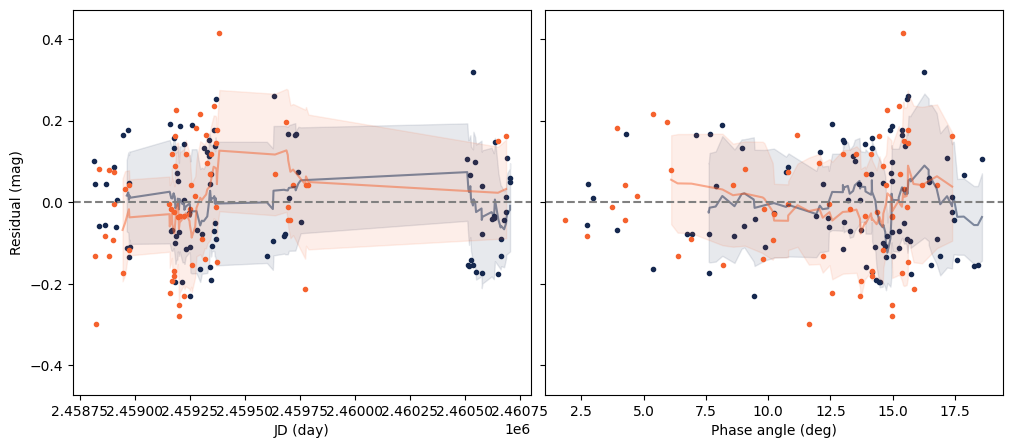

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True, gridspec_kw={"wspace": 0.03})

for filtnum in pdf["i:fid"].unique():
    
    # By filter
    cond = pdf["i:fid"] == filtnum
    color = fink_colors[filtnum-1]
    
    # vs Time
    ax[0].scatter(pdf.loc[cond, "i:jd"], pdf.loc[cond, "res_sHG1G2"], color=color, marker=".")
    sorted = pdf[cond].sort_values("i:jd")
    x = sorted["i:jd"]
    y = sorted["res_sHG1G2"].rolling(10).mean()
    sy = sorted["res_sHG1G2"].rolling(10).std()
    ax[0].fill_between(x, y-sy, y+sy, color=color, alpha=0.1)
    ax[0].plot(x, y, color=color, alpha=0.5)
    
    # vs Phase angle
    ax[1].scatter(pdf.loc[cond, "Phase"], pdf.loc[cond, "res_sHG1G2"], color=color, marker=".")
    sorted = pdf[cond].sort_values("Phase")
    x = sorted["Phase"]
    y = sorted["res_sHG1G2"].rolling(10).mean()
    sy = sorted["res_sHG1G2"].rolling(10).std()
    ax[1].fill_between(x, y-sy, y+sy, color=color, alpha=0.1)
    ax[1].plot(x, y, color=color, alpha=0.5)
    
ax[0].axhline(0, ls="--", color="grey")
ax[1].axhline(0, ls="--", color="grey")

max_res = 0.4
max_res = 3.5* np.std( pdf['res_sHG1G2'])
ax[0].set_ylim(-max_res, max_res)
ax[0].set_xlabel("JD (day)")
ax[1].set_xlabel("Phase angle (deg)")
ax[0].set_ylabel("Residual (mag)")

# Fit ssHG1G2

## Synodic to sidereal

In [44]:
jd = pdf["i:jd"].tolist()
jd2 = (pdf["i:jd"].values +  period / 24.0).tolist()

eph = ssptools.ephemcc(name, jd, tcoor=2, observer="500")
eph2 = ssptools.ephemcc(name, jd2, tcoor=2, observer="500")

In [45]:
pdf['jd_ltc'] = compute_light_travel_correction( pdf["i:jd"], eph['Dobs'] )

In [46]:
for i in range(len(jd)):
    eph.loc[i, "angle"] = angle_between_vectors(
        eph.loc[i, ["px", "py", "pz"]].values, eph2.loc[i, ["px", "py", "pz"]].values
    )

In [47]:
# Sidereal Rotation in days
sidereal_period = synodic_to_sidereal(period / 24.0, 000)
print(sidereal_period * 24)

5.184026269346445


5.184026269346445 5.184432878768678 5.1836196599242115


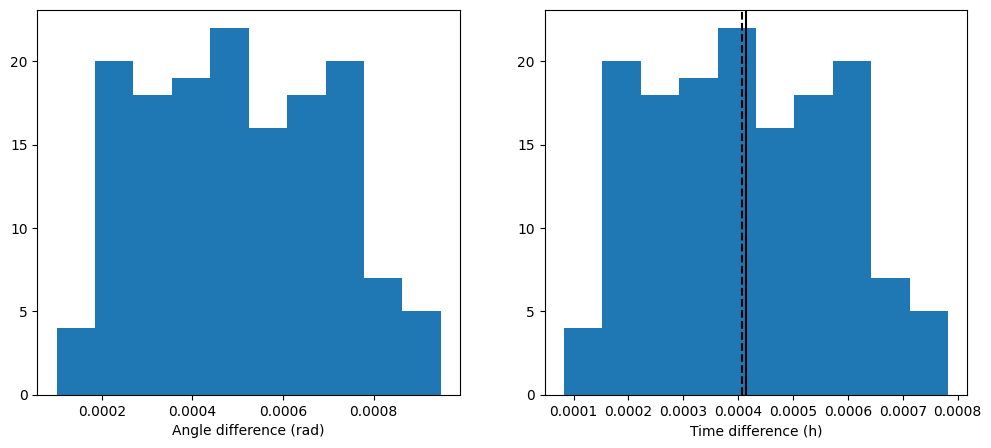

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(eph["angle"])

dephase = (eph["angle"] / (2 * np.pi)) * period
ax[1].hist(dephase)

ax[1].axvline( np.mean( dephase), color='black' )
ax[1].axvline( np.median( dephase), color='black', ls='dashed' )
# ax[1].axvline( np.mean( dephase), ls='dotted' )

ax[0].set_xlabel("Angle difference (rad)")
ax[1].set_xlabel("Time difference (h)")

print( period, period + np.median( dephase ), period - np.median( dephase ) )

In [49]:
(period - np.median( dephase )), 27.47

(5.1836196599242115, 27.47)

In [50]:
per_arr = sidereal_period + np.linspace(-1,1,100)* 1e-5


In [51]:

per_arr = sidereal_period + np.linspace(-1,1,15)* 1e-5


out_per = pd.DataFrame(index=range(2*len(per_arr)), 
                   columns=['p_in', "alpha0", "delta0", "period", "a_b", "a_c", "chi2red", "rms"])
for i, Ps in enumerate(per_arr):

    # Initial guess - V1
    ra0 = np.radians(fit_shg1g2["alpha0"])
    de0 = np.radians(fit_shg1g2["delta0"])
    p0 = [
        fit_shg1g2["H_1"],
        fit_shg1g2["G1_1"],
        fit_shg1g2["G2_1"],
        ra0,
        de0,
        Ps,
        fit_shg1g2['a_b'],
        fit_shg1g2['a_c'],
        0.0,
    ]

    # Constrained Fit
    fit_sshg1g2 = estimate_sso_params(
        pdf["i:magpsf_red"],
        pdf["i:sigmapsf"],
        np.radians(pdf["Phase"]),
        pdf["i:fid"],
        ra=np.radians(pdf["i:ra"]),
        dec=np.radians(pdf["i:dec"]),
        jd=pdf["jd_ltc"],
        model="SSHG1G2",
        p0=p0,
    )

    # print(f'{i:1d}  {ra0:4.2f} {de0:5.2f}    {fit_sshg1g2["rms"]:.3f} ')
    print(i, ra0,de0,Ps, fit_sshg1g2["status"])

    if fit_sshg1g2["status"] ==2:
        out_per.loc[2*i, "p_in"] = Ps
        out_per.loc[2*i, "alpha0"] = fit_sshg1g2["alpha0"]
        out_per.loc[2*i, "delta0"] = fit_sshg1g2["delta0"]
        out_per.loc[2*i, "period"] = fit_sshg1g2["period"]
        out_per.loc[2*i, "a_b"] = fit_sshg1g2["a_b"]
        out_per.loc[2*i, "a_c"] = fit_sshg1g2["a_c"]
        out_per.loc[2*i, "chi2red"] = fit_sshg1g2["chi2red"]
        out_per.loc[2*i, "rms"] = fit_sshg1g2["rms"]





    # Initial guess - V2
    ra0 = (np.pi + np.radians(fit_shg1g2["alpha0"])) % (2 * np.pi)
    de0 = -np.radians(fit_shg1g2["delta0"])
    p0 = [
        fit_shg1g2["H_1"],
        fit_shg1g2["G1_1"],
        fit_shg1g2["G2_1"],
        ra0,
        de0,
        Ps,
        fit_shg1g2['a_b'],
        fit_shg1g2['a_c'],
        0.0,
    ]

    # Constrained Fit
    fit_sshg1g2 = estimate_sso_params(
        pdf["i:magpsf_red"],
        pdf["i:sigmapsf"],
        np.radians(pdf["Phase"]),
        pdf["i:fid"],
        ra=np.radians(pdf["i:ra"]),
        dec=np.radians(pdf["i:dec"]),
        jd=pdf["jd_ltc"],
        model="SSHG1G2",
        p0=p0,
    )
    print(i, ra0,de0,Ps, fit_sshg1g2["status"])
    # print(f'{i:1d}  {ra0:4.2f} {de0:5.2f}    {fit_sshg1g2["rms"]:.3f} ')

    if fit_sshg1g2["status"] ==2:
        out_per.loc[2*i+1, "p_in"] = Ps
        out_per.loc[2*i+1, "alpha0"] = fit_sshg1g2["alpha0"]
        out_per.loc[2*i+1, "delta0"] = fit_sshg1g2["delta0"]
        out_per.loc[2*i+1, "period"] = fit_sshg1g2["period"]
        out_per.loc[2*i+1, "a_b"] = fit_sshg1g2["a_b"]
        out_per.loc[2*i+1, "a_c"] = fit_sshg1g2["a_c"]
        out_per.loc[2*i+1, "chi2red"] = fit_sshg1g2["chi2red"]
        out_per.loc[2*i+1, "rms"] = fit_sshg1g2["rms"]



0 1.0514389359483052 1.199155998144783 0.21599109455610185 3
0 4.193031589538098 -1.199155998144783 0.21599109455610185 2
1 1.0514389359483052 1.199155998144783 0.21599252312753042 3
1 4.193031589538098 -1.199155998144783 0.21599252312753042 2
2 1.0514389359483052 1.199155998144783 0.21599395169895902 2
2 4.193031589538098 -1.199155998144783 0.21599395169895902 3
3 1.0514389359483052 1.199155998144783 0.2159953802703876 2
3 4.193031589538098 -1.199155998144783 0.2159953802703876 2
4 1.0514389359483052 1.199155998144783 0.21599680884181616 2
4 4.193031589538098 -1.199155998144783 0.21599680884181616 2
5 1.0514389359483052 1.199155998144783 0.21599823741324473 2
5 4.193031589538098 -1.199155998144783 0.21599823741324473 2
6 1.0514389359483052 1.199155998144783 0.2159996659846733 2
6 4.193031589538098 -1.199155998144783 0.2159996659846733 2
7 1.0514389359483052 1.199155998144783 0.21600109455610186 2
7 4.193031589538098 -1.199155998144783 0.21600109455610186 2
8 1.0514389359483052 1.19915

In [52]:
out_per

,p_in,alpha0,delta0,period,a_b,a_c,chi2red,rms
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.215991,280.142646,18.311119,0.215986,1.510847,1.57239,10.250987,0.053667
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.215993,280.14305,18.311889,0.215986,1.510846,1.572399,10.250998,0.053667
4,0.215994,88.17169,22.922812,0.216005,1.498912,1.439009,16.546357,0.072662
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.215995,88.171336,22.924746,0.216005,1.498912,1.439008,16.546294,0.072662
7,0.215995,280.142657,18.310924,0.215986,1.510847,1.572385,10.250994,0.053667
8,0.215997,88.170469,22.926336,0.216005,1.498912,1.439006,16.546223,0.072662
9,0.215997,266.803533,-29.752749,0.216005,1.504879,1.440026,16.793593,0.073847


5.183641
5.183786269346444 5.184266269346445 5.184026269346445


Text(0, 0.5, 'RMS (mag)')

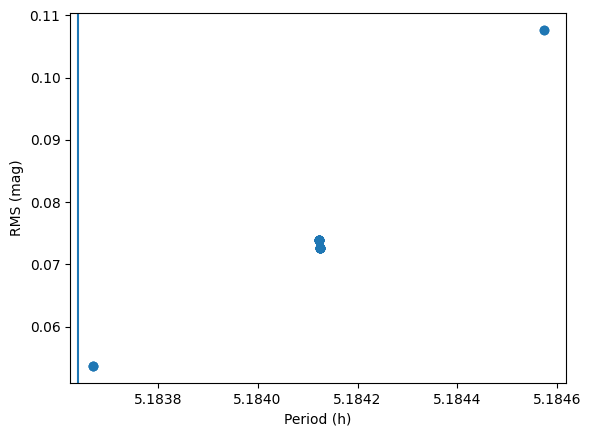

In [63]:
fig, ax = plt.subplots()
ax.scatter(out_per.period*24, out_per.rms )
ax.axvline( ssocard.spin[0].period.value)
print(ssocard.spin[0].period.value)
# ax.set_xlim(per_arr.min(), per_arr.max())
print(per_arr.min()*24, per_arr.max()*24, sidereal_period* 24)

ax.set_xlabel("Period (h)")
ax.set_ylabel("RMS (mag)")

In [ ]:
print( fit_shg1g2["alpha0"], fit_shg1g2["delta0"])
fit_shg1g2["alpha0"] = 320.
fit_shg1g2["delta0"] = 75.

In [ ]:
ra_120 = np.linspace(0, 2 * np.pi, 4)[:-1]
ra_arr = np.append(ra_120, ra_120[:]+np.radians(60) )
de_arr = np.append( np.full(3, np.pi/3.), np.full(3, -np.pi/3.) )


xx = np.linspace(0, 360, 13)[:-1]
yy = np.linspace(-90, 90, 6)[1:-1]
X, Y = np.meshgrid(xx, yy)
ra_arr = np.radians(X.ravel())
de_arr = np.radians(Y.ravel())

In [ ]:
# Test for 6605 to force initial value close to sidereal DAMIT
# sidereal_period = 118.69/24.
# print(sidereal_period*24)


# sidereal_period = 11.6027/24  # 5209
# sidereal_period = 12.2527/24 # 4209
sidereal_period = (period - np.median( dephase ))/24
# sidereal_period = 27.47/24.
print(sidereal_period * 24)

out = pd.DataFrame(index=range(6), 
                   columns=["ra0", 'de0', "alpha0", "delta0", "period", "a_b", "a_c", "chi2red", "rms"])
for i, (ra0, de0) in enumerate(zip(ra_arr, de_arr)):

    # Initial guess - V1
    p0 = [
        fit_shg1g2["H_1"],
        fit_shg1g2["G1_1"],
        fit_shg1g2["G2_1"],
        ra0,
        de0,
        sidereal_period,
        fit_shg1g2['a_b'],
        fit_shg1g2['a_c'],
        0.0,
    ]

    # Constrained Fit
    fit_sshg1g2 = estimate_sso_params(
        pdf["i:magpsf_red"],
        pdf["i:sigmapsf"],
        np.radians(pdf["Phase"]),
        pdf["i:fid"],
        ra=np.radians(pdf["i:ra"]),
        dec=np.radians(pdf["i:dec"]),
        jd=pdf["jd_ltc"],
        model="SSHG1G2",
        p0=p0,
    )

    print(f'{i:1d}  {ra0:4.2f} {de0:5.2f}    {fit_sshg1g2["rms"]:.3f} ')

    out.loc[i, "ra0"] = np.degrees(ra0)
    out.loc[i, "de0"] = np.degrees(de0)
    out.loc[i, "alpha0"] = fit_sshg1g2["alpha0"]
    out.loc[i, "delta0"] = fit_sshg1g2["delta0"]
    out.loc[i, "period"] = fit_sshg1g2["period"]
    out.loc[i, "a_b"] = fit_sshg1g2["a_b"]
    out.loc[i, "a_c"] = fit_sshg1g2["a_c"]
    out.loc[i, "chi2red"] = fit_sshg1g2["chi2red"]
    out.loc[i, "rms"] = fit_sshg1g2["rms"]



In [ ]:
out

In [ ]:
import numpy as np
import matplotlib.pyplot as pl
import scipy.stats as st
from scipy.interpolate import LinearNDInterpolator


sorted = out.sort_values(by="alpha0")
x = sorted['alpha0'].to_list()
y = sorted['delta0'].to_list()
z = sorted['rms'].to_list()

# Define the grid for the kernel density estimate
xmin, xmax = 0, 360
ymin, ymax = -90, 90


interp = LinearNDInterpolator(list(zip(x, y)), z)

xx = np.linspace(0, 360, 36)
yy = np.linspace(-90, 90, 18)
X, Y = np.meshgrid(xx, yy, indexing='ij')
Z = interp(X, Y)



fig = pl.figure()
ax = fig.gca()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)


# Peform the kernel density estimate
kde = True
if kde: 
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x, y])
    kernel = st.gaussian_kde(values)
    f = np.reshape(kernel(positions).T, xx.shape)
    ax.imshow(np.rot90(f), cmap='Blues', extent=[xmin, xmax, ymin, ymax])

else: 
    ax.pcolormesh(X, Y, Z, cmap='Blues')#, extent=[xmin, xmax, ymin, ymax])


# Contourf plot
# cfset = ax.contourf(xx, yy, f, cmap='Blues')
## Or kernel density estimate plot instead of the contourf plot
# Contour plot
# cset = ax.contour(xx, yy, f, colors='k')
# ax.clabel(cset, inline=1, fontsize=10)

ax.scatter(x, y, zorder=10, c=out.rms.to_list(), cmap='Reds', s=5, label='trials')
if ssocard.spin[0].RA0.value is not None:
    # Plot the DAMIT value
    ax.scatter(
        ssocard.spin[0].RA0.value,
        ssocard.spin[0].DEC0.value,
        marker="x",
        color="red",
        s=100,
        label="ssocard",
    )

# Axes
ax.set_xlabel('alpha0')
ax.set_ylabel('delta0')
ax.legend()

pl.show()

In [ ]:
p = 10
L = 6

0.5 * (p/24)**2 / (L*365) 

In [ ]:
plt.hist(out.rms)

In [ ]:

import numpy as np
def f(x, y, z):
    return 2 * x**3 + 3 * y**2 - z
x = np.linspace(1, 4, 11)
y = np.linspace(4, 7, 22)
z = np.linspace(7, 9, 33)
xg, yg ,zg = np.meshgrid(x, y, z, indexing='ij', sparse=True)
data = f(xg, yg, zg)

In [ ]:
print("       sHG1G2  ssHG1G2  ss(alt)")
print(
    f"RMS  : {fit_shg1g2['rms']:6.3f}  {fit_sshg1g2['rms']:6.3f}  {fit_sshg1g2_alt['rms']:6.3f}"
)
print(
    f"chi2 : {fit_shg1g2['chi2red']:6.3f}  {fit_sshg1g2['chi2red']:6.3f}  {fit_sshg1g2_alt['chi2red']:6.3f}"
)
print()
print(
    f"H_1  : {fit_shg1g2['H_1']:6.2f}  {fit_sshg1g2['H_1']:6.2f}  {fit_sshg1g2_alt['H_1']:6.2f}"
)
print(
    f"H_2  : {fit_shg1g2['H_2']:6.2f}  {fit_sshg1g2['H_2']:6.2f}  {fit_sshg1g2_alt['H_2']:6.2f}"
)
print(
    f"G1_1 : {fit_shg1g2['G1_1']:6.2f}  {fit_sshg1g2['G1_1']:6.2f}  {fit_sshg1g2_alt['G1_1']:6.2f}"
)
print(
    f"G1_2 : {fit_shg1g2['G1_2']:6.2f}  {fit_sshg1g2['G1_2']:6.2f}  {fit_sshg1g2_alt['G1_2']:6.2f}"
)
print(
    f"G2_1 : {fit_shg1g2['G2_1']:6.2f}  {fit_sshg1g2['G2_1']:6.2f}  {fit_sshg1g2_alt['G2_1']:6.2f}"
)
print(
    f"G2_2 : {fit_shg1g2['G2_2']:6.2f}  {fit_sshg1g2['G2_2']:6.2f}  {fit_sshg1g2_alt['G2_2']:6.2f}"
)

print()
print(
    f"RA0  : {fit_shg1g2['alpha0']:6.1f}  {fit_sshg1g2['alpha0']:6.1f}  {fit_sshg1g2_alt['alpha0']:6.1f}"
)
print(
    f"DEC0 : {fit_shg1g2['delta0']:6.1f}  {fit_sshg1g2['delta0']:6.1f}  {fit_sshg1g2_alt['delta0']:6.1f}"
)
print(
    f"P(h) : {period:6.3f}  {fit_sshg1g2['period']*24:6.3f}  {fit_sshg1g2_alt['period']*24:6.3f}"
)
print(f"a/b  :         {fit_sshg1g2['a_b']:6.2f}  {fit_sshg1g2_alt['a_b']:6.2f}")
print(f"a/c  :         {fit_sshg1g2['a_c']:6.2f}  {fit_sshg1g2_alt['a_c']:6.2f}")


root = f"{num}_{name}".replace(" ", "_")
with open(os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}.csv"), "w") as f:
    f.write(f"par,sHG1G2,ssHG1G2,ssHG1G2_alt\n")
    f.write(f"RMS,{fit_shg1g2['rms']},{fit_sshg1g2['rms']},{fit_sshg1g2_alt['rms']}\n")
    f.write(
        f"chi2,{fit_shg1g2['chi2red']},{fit_sshg1g2['chi2red']},{fit_sshg1g2_alt['chi2red']}\n"
    )

    f.write(f"H_1,{fit_shg1g2['H_1']},{fit_sshg1g2['H_1']},{fit_sshg1g2_alt['H_1']}\n")
    f.write(
        f"err_H_1,{fit_shg1g2['err_H_1']},{fit_sshg1g2['err_H_1']},{fit_sshg1g2_alt['err_H_1']}\n"
    )
    f.write(
        f"G1_1,{fit_shg1g2['G1_1']},{fit_sshg1g2['G1_1']},{fit_sshg1g2_alt['G1_1']}\n"
    )
    f.write(
        f"G2_1,{fit_shg1g2['G2_1']},{fit_sshg1g2['G2_1']},{fit_sshg1g2_alt['G2_1']}\n"
    )
    f.write(
        f"err_G1_1,{fit_shg1g2['err_G1_1']},{fit_sshg1g2['err_G1_1']},{fit_sshg1g2_alt['err_G1_1']}\n"
    )
    f.write(
        f"err_G2_1,{fit_shg1g2['err_G2_1']},{fit_sshg1g2['err_G2_1']},{fit_sshg1g2_alt['err_G2_1']}\n"
    )

    f.write(f"H_2,{fit_shg1g2['H_2']},{fit_sshg1g2['H_2']},{fit_sshg1g2_alt['H_2']}\n")
    f.write(
        f"err_H_2,{fit_shg1g2['err_H_2']},{fit_sshg1g2['err_H_2']},{fit_sshg1g2_alt['err_H_2']}\n"
    )
    f.write(
        f"G1_2,{fit_shg1g2['G1_2']},{fit_sshg1g2['G1_2']},{fit_sshg1g2_alt['G1_2']}\n"
    )
    f.write(
        f"G2_2,{fit_shg1g2['G2_2']},{fit_sshg1g2['G2_2']},{fit_sshg1g2_alt['G2_2']}\n"
    )
    f.write(
        f"err_G1_2,{fit_shg1g2['err_G1_2']},{fit_sshg1g2['err_G1_2']},{fit_sshg1g2_alt['err_G1_2']}\n"
    )
    f.write(
        f"err_G2_2,{fit_shg1g2['err_G2_2']},{fit_sshg1g2['err_G2_2']},{fit_sshg1g2_alt['err_G2_2']}\n"
    )

    f.write(
        f"alpha0,{fit_shg1g2['alpha0']},{fit_sshg1g2['alpha0']},{fit_sshg1g2_alt['alpha0']}\n"
    )
    f.write(
        f"delta0,{fit_shg1g2['delta0']},{fit_sshg1g2['delta0']},{fit_sshg1g2_alt['delta0']}\n"
    )
    f.write(
        f"err_alpha0,{fit_shg1g2['err_alpha0']},{fit_sshg1g2['err_alpha0']},{fit_sshg1g2_alt['err_alpha0']}\n"
    )
    f.write(
        f"err_delta0,{fit_shg1g2['err_delta0']},{fit_sshg1g2['err_delta0']},{fit_sshg1g2_alt['err_delta0']}\n"
    )

    f.write(f"P,{period},{fit_sshg1g2['period']*24},{fit_sshg1g2_alt['period']*24}\n")
    f.write(f"a_b,,{fit_sshg1g2['a_b']},{fit_sshg1g2_alt['a_b']}\n")
    f.write(f"a_c,,{fit_sshg1g2['a_c']},{fit_sshg1g2_alt['a_c']}\n")
    f.write(
        f"err_P, ,{fit_sshg1g2['err_period']*24},{fit_sshg1g2_alt['err_period']*24}\n"
    )
    f.write(f"err_a_b,,{fit_sshg1g2['err_a_b']},{fit_sshg1g2_alt['err_a_b']}\n")
    f.write(f"err_a_c,,{fit_sshg1g2['err_a_c']},{fit_sshg1g2_alt['err_a_c']}\n")

In [ ]:
# --------------------------------------------------------------------------------
# Compute residuals
for filtnum in pdf["i:fid"].unique():

    # Input variables
    cond = pdf["i:fid"] == filtnum

    coord = SkyCoord(
        ra=pdf.loc[cond, "i:ra"], dec=pdf.loc[cond, "i:dec"], unit=("deg", "deg")
    )
    data_ra = coord.ra.rad
    data_dec = coord.dec.rad
    data_jd = pdf.loc[cond, "jd_ltc"]
    data_phase = np.radians(pdf.loc[cond, "Phase"])
    data_mag = pdf.loc[cond, "i:magpsf_red"]

    pha = [data_phase.values, data_ra, data_dec, data_jd.values]

    # ssHG1G2
    model = func_sshg1g2(
        pha,
        fit_sshg1g2[f"H_{filtnum}"],
        fit_sshg1g2[f"G1_{filtnum}"],
        fit_sshg1g2[f"G2_{filtnum}"],
        np.radians(fit_sshg1g2["alpha0"]),
        np.radians(fit_sshg1g2["delta0"]),
        fit_sshg1g2["period"],
        fit_sshg1g2["a_b"],
        fit_sshg1g2["a_c"],
        fit_sshg1g2["phi0"],
    )

    model_alt = func_sshg1g2(
        pha,
        fit_sshg1g2_alt[f"H_{filtnum}"],
        fit_sshg1g2_alt[f"G1_{filtnum}"],
        fit_sshg1g2_alt[f"G2_{filtnum}"],
        np.radians(fit_sshg1g2_alt["alpha0"]),
        np.radians(fit_sshg1g2_alt["delta0"]),
        fit_sshg1g2_alt["period"],
        fit_sshg1g2_alt["a_b"],
        fit_sshg1g2_alt["a_c"],
        fit_sshg1g2_alt["phi0"],
    )

    pdf.loc[cond, f"res_ssHG1G2"] = data_mag - model
    pdf.loc[cond, f"res_ssHG1G2_alt"] = data_mag - model_alt

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, gridspec_kw={"wspace": 0.03})

max_res = 0.2
bins = np.linspace(-max_res, max_res, 50)
for i, filtnum in enumerate(pdf["i:fid"].unique()):
    cond = pdf["i:fid"] == filtnum
    mu, std = np.mean(pdf.loc[cond, "residuals"]), np.std(pdf.loc[cond, "residuals"])
    ax[0].hist(
        pdf.loc[cond, "residuals"],
        bins=bins,
        alpha=0.5,
        color=fink_colors[i],
        label=f"{filtnum}: {mu:5.2f}±{std:.2f}",
    )

    # V1
    mu, std = np.mean(pdf.loc[cond, "res_ssHG1G2"]), np.std(
        pdf.loc[cond, "res_ssHG1G2"]
    )
    ax[1].hist(
        pdf.loc[cond, "res_ssHG1G2"],
        bins=bins,
        alpha=0.5,
        color=fink_colors[i],
        label=f"{filtnum}: {mu:5.2f}±{std:.2f}",
    )

    # V2 - alt
    mu, std = np.mean(pdf.loc[cond, "res_ssHG1G2_alt"]), np.std(
        pdf.loc[cond, "res_ssHG1G2_alt"]
    )
    ax[2].hist(
        pdf.loc[cond, "res_ssHG1G2_alt"],
        bins=bins,
        alpha=0.5,
        color=fink_colors[i],
        label=f"{filtnum}: {mu:5.2f}±{std:.2f}",
    )


ax[0].set_title("sHG1G2")
ax[1].set_title("ssHG1G2")
ax[2].set_title("ssHG1G2 (alt spin)")
for a in ax:
    a.set_xlabel("Residuals (mag)")
    a.legend(loc="upper left")

fig.tight_layout()
fig.savefig(
    os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}_res_hist.png"),
    dpi=180,
    facecolor="white",
)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, gridspec_kw={"wspace": 0.03})

for i, filtnum in enumerate(pdf["i:fid"].unique()):
    cond = pdf["i:fid"] == filtnum
    ax[0].scatter(
        pdf["i:jd"][cond],
        pdf["residuals"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[1].scatter(
        pdf["i:jd"][cond],
        pdf["res_ssHG1G2"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[2].scatter(
        pdf["i:jd"][cond],
        pdf["res_ssHG1G2_alt"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )

for a in ax:
    a.axhline(0, ls="--", color="grey")
    a.set_xlabel("JD (day)")
ax[0].set_ylabel("Residual (mag)")

ax[0].set_title("sHG1G2")
ax[1].set_title("ssHG1G2")
ax[2].set_title("ssHG1G2 (alt spin)")

fig.tight_layout()
fig.savefig(
    os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}_res_jd.png"),
    dpi=180,
    facecolor="white",
)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, gridspec_kw={"wspace": 0.03})

for i, filtnum in enumerate(pdf["i:fid"].unique()):
    cond = pdf["i:fid"] == filtnum
    ax[0].scatter(
        pdf["Phase"][cond],
        pdf["residuals"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[1].scatter(
        pdf["Phase"][cond],
        pdf["res_ssHG1G2"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[2].scatter(
        pdf["Phase"][cond],
        pdf["res_ssHG1G2_alt"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )

for a in ax:
    a.axhline(0, ls="--", color="grey")
    a.set_xlabel("Phase angle (deg)")
ax[0].set_ylabel("Residual (mag)")

ax[0].set_title("sHG1G2")
ax[1].set_title("ssHG1G2")
ax[2].set_title("ssHG1G2 (alt spin)")

fig.tight_layout()
fig.savefig(
    os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}_res_phase.png"),
    dpi=180,
    facecolor="white",
)